## Train A Test A

Category distribution:
Device Type
Coordinator    8650
Socket         8300
Bulb           3839
Motion          206
Door             69
Button           17
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.94      0.94      0.94       724
      Button       1.00      0.33      0.50         3
 Coordinator       0.97      0.97      0.97      1674
        Door       1.00      0.89      0.94        18
      Motion       0.82      0.73      0.77        44
      Socket       0.97      0.98      0.98      1754

    accuracy                           0.96      4217
   macro avg       0.95      0.81      0.85      4217
weighted avg       0.96      0.96      0.96      4217

Weighted F1-Score: 0.9644


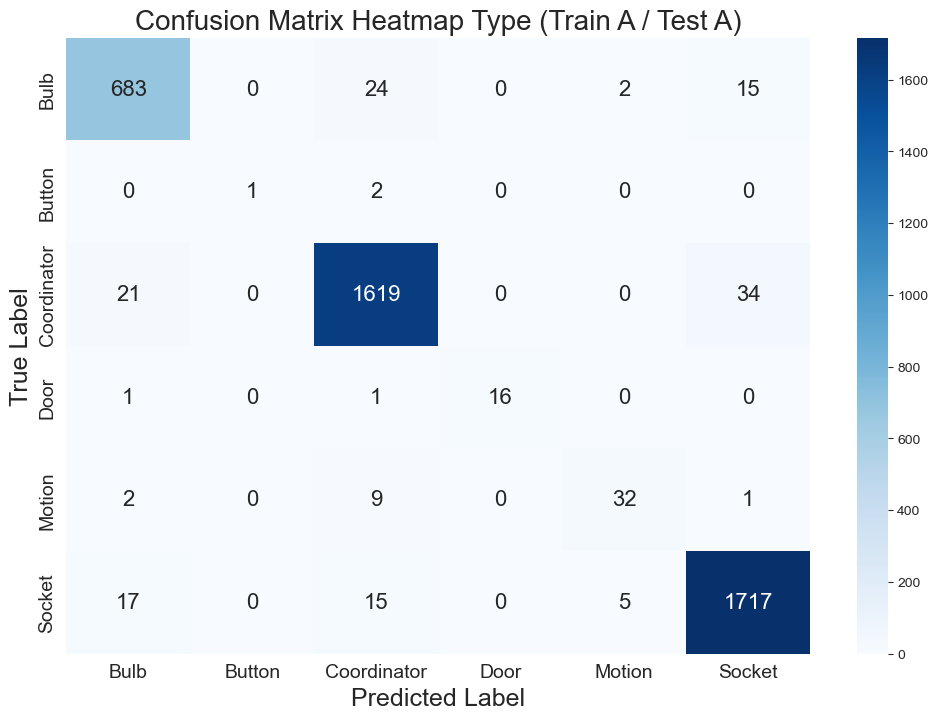

In [12]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)


X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train A / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


Category distribution:
2     8650
13    2949
12    2606
11    2385
3     1165
10     742
6      726
7      669
8      537
5      221
9      194
4      139
1       50
0       17
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       1.00      0.67      0.80         3
        Aqara Door 1       0.80      1.00      0.89         8
         Coordinator       0.97      0.97      0.97      1747
       Ledvance Bulb       0.92      0.92      0.92       229
Ledvance Smart+ Plug       0.93      0.80      0.86        35
    Ledvance Z3 Plug       0.79      0.76      0.78        41
           Moes Bulb       0.95      0.89      0.92       132
      Philips Lamp 1       0.81      0.72      0.76       122
      Philips Lamp 2       0.83      0.88      0.85        97
      Philips Lamp 3       0.82      0.79      0.80        42
      Philips Motion       0.83      0.83      0.83       145
        Power Plug 1       0.95      0.93      0.94 

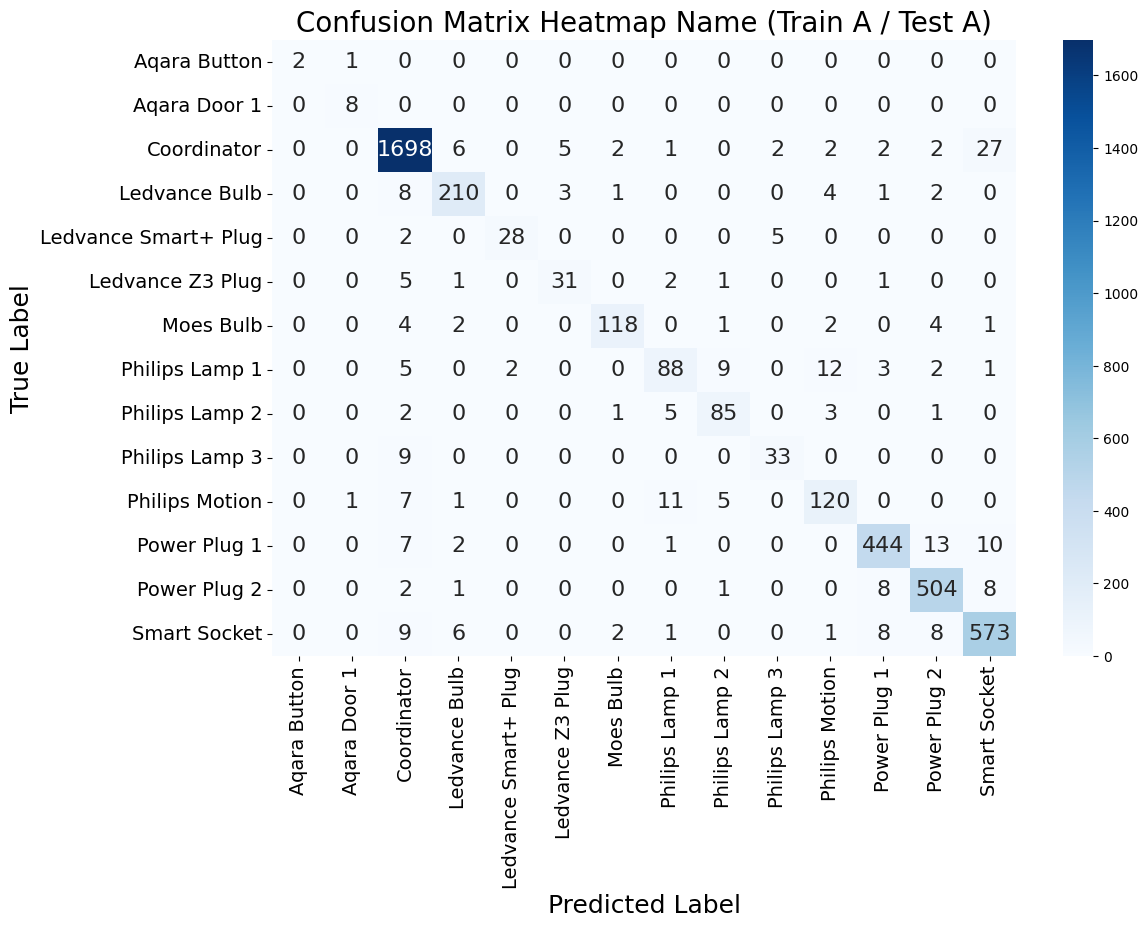

In [1]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
Device Type
Coordinator    8650
Socket         8300
Bulb           3839
Motion          206
Door             69
Button           17
Name: count, dtype: int64

5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier

Fold 1/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:24:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9485
  Precision (avg): 0.9091
  Recall (avg):    0.9551
  F1-Macro:        0.9261
  F1-Weighted:     0.9493

Fold 2/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:24:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9483
  Precision (avg): 0.9048
  Recall (avg):    0.8434
  F1-Macro:        0.8655
  F1-Weighted:     0.9486

Fold 3/5:
----------------------------------------


...

  Accuracy:        0.9421
  Precision (avg): 0.8926
  Recall (avg):    0.9481
  F1-Macro:        0.9114
  F1-Weighted:     0.9433

Fold 4/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:25:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9509
  Precision (avg): 0.9100
  Recall (avg):    0.9529
  F1-Macro:        0.9296
  F1-Weighted:     0.9514

Fold 5/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:26:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9450
  Precision (avg): 0.8998
  Recall (avg):    0.9476
  F1-Macro:        0.9196
  F1-Weighted:     0.9461

CROSS-VALIDATION SUMMARY (mean ± std)
Accuracy:        0.9470 ± 0.0031
Precision (avg): 0.9033 ± 0.0064
Recall (avg):    0.9294 ± 0.0431
F1-Macro:        0.9104 ± 0.0233
F1-Weighted:     0.9477 ± 0.0028

MERGED CLASSIFICATION REPORT (All Folds Combined)
              precision    recall  f1-score   support

        Bulb       0.88      0.96      0.92      3839
      Button       1.00      0.94      0.97        17
 Coordinator       0.97      0.94      0.96      8650
        Door       0.97      0.91      0.94        69
      Motion       0.62      0.88      0.73       206
      Socket       0.97      0.95      0.96      8300

    accuracy                           0.95     21081
   macro avg       0.90      0.93      0.91     21081
weighted avg       0.95      0.95      0.95     21081



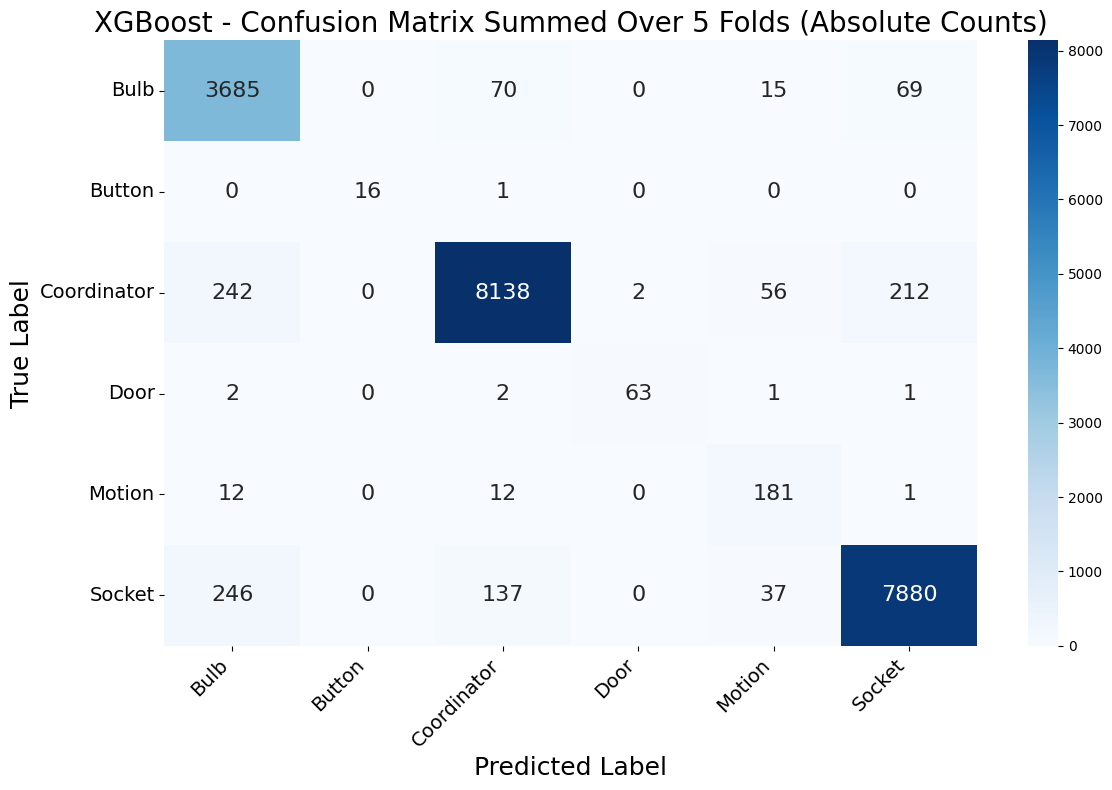

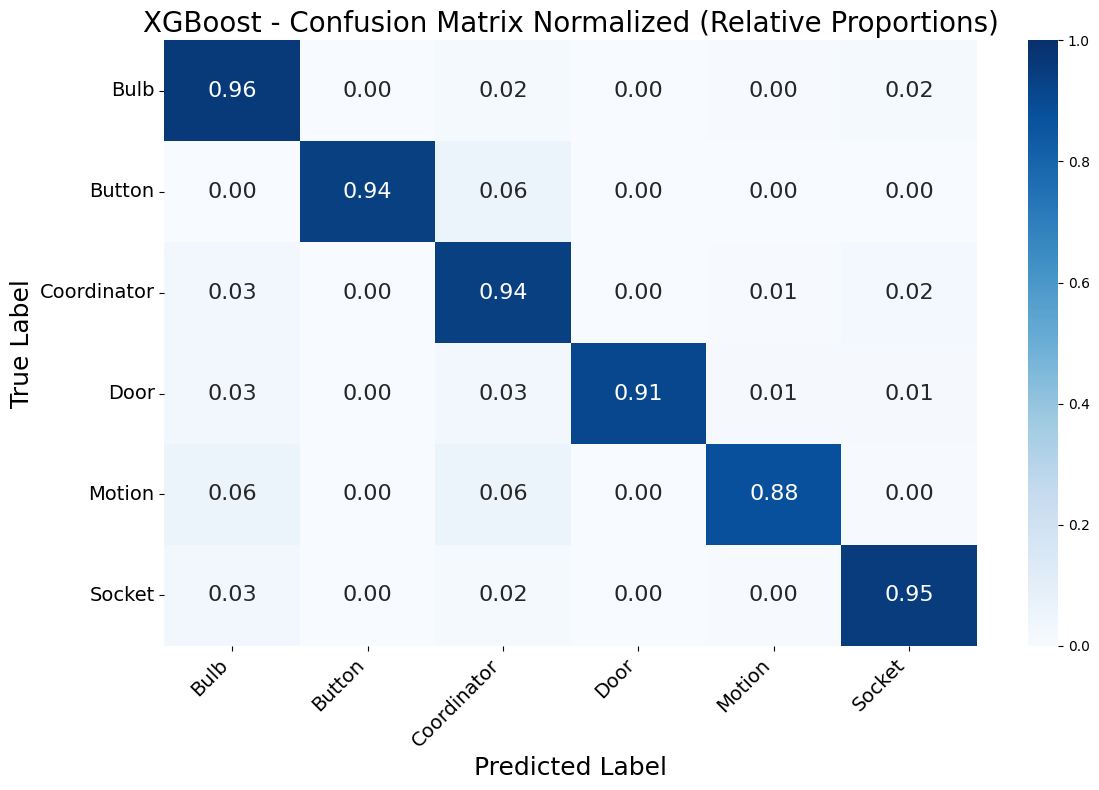


Confusion matrices saved to /mnt/user-data/outputs/


In [2]:
# Classification with 5-Fold Cross-Validation using XGBoost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())
print()

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    
    # Convert class weights to sample weights for XGBoost
    sample_weights = np.array([class_weights[i] for i in y_train])
    
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    )
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predict
    y_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Summed Over 5 Folds (Absolute Counts)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_xgboost_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(12, 8))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Normalized (Relative Proportions)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_xgboost_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")

Category distribution:
3     8650
14    2949
13    2606
12    2385
4     1165
11     742
7      726
8      669
9      537
6      221
10     194
5      139
1       50
0       17
2       12
16       9
15       6
Name: count, dtype: int64

Number of classes: 17
Total samples: 21077

5-FOLD CROSS-VALIDATION RESULTS

Fold 1/5:
----------------------------------------
  Accuracy:        0.9303
  Precision (avg): 0.9101
  Recall (avg):    0.8751
  F1-Macro:        0.8873
  F1-Weighted:     0.9302

Fold 2/5:
----------------------------------------
  Accuracy:        0.9435
  Precision (avg): 0.8796
  Recall (avg):    0.8267
  F1-Macro:        0.8424
  F1-Weighted:     0.9433

Fold 3/5:
----------------------------------------
  Accuracy:        0.9345
  Precision (avg): 0.8540
  Recall (avg):    0.8262
  F1-Macro:        0.8328
  F1-Weighted:     0.9342

Fold 4/5:
----------------------------------------
  Accuracy:        0.9340
  Precision (avg): 0.9320
  Recall (avg):    0.8663
  F1-Macro:

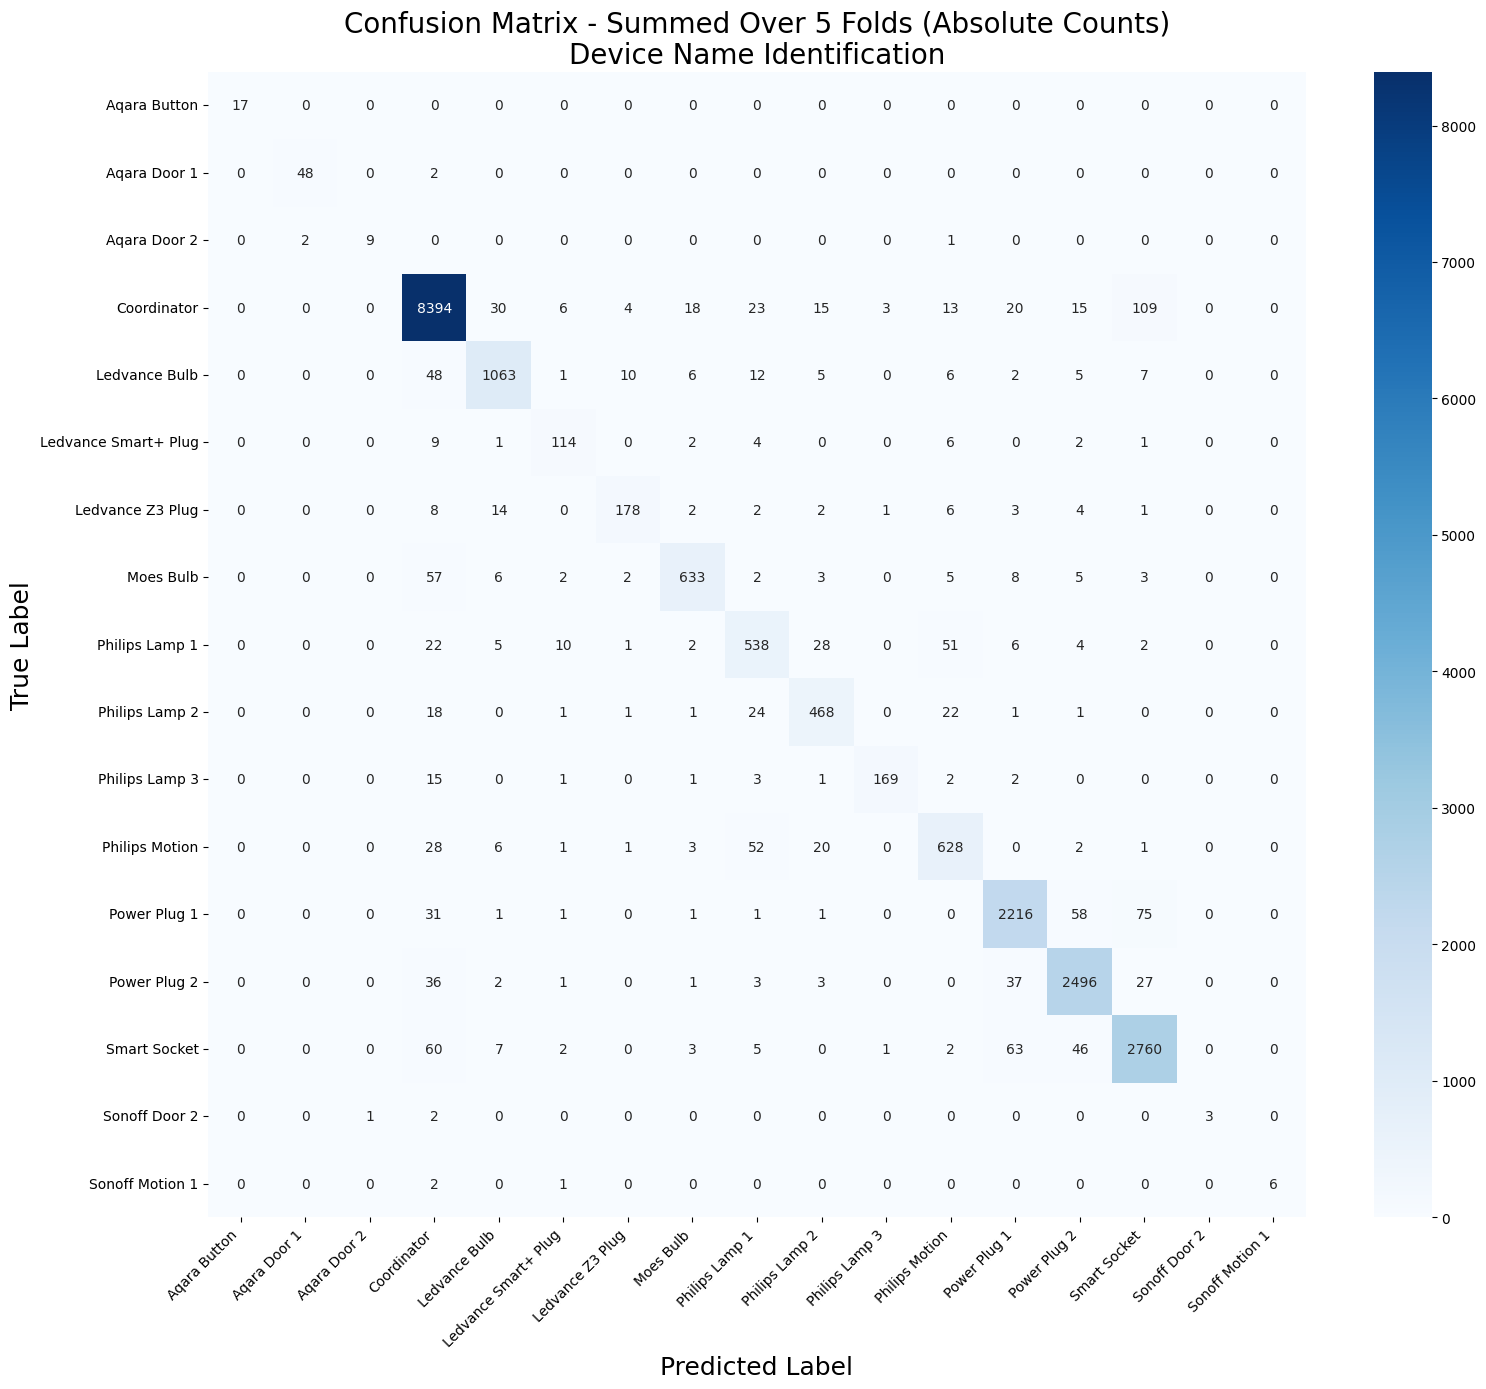

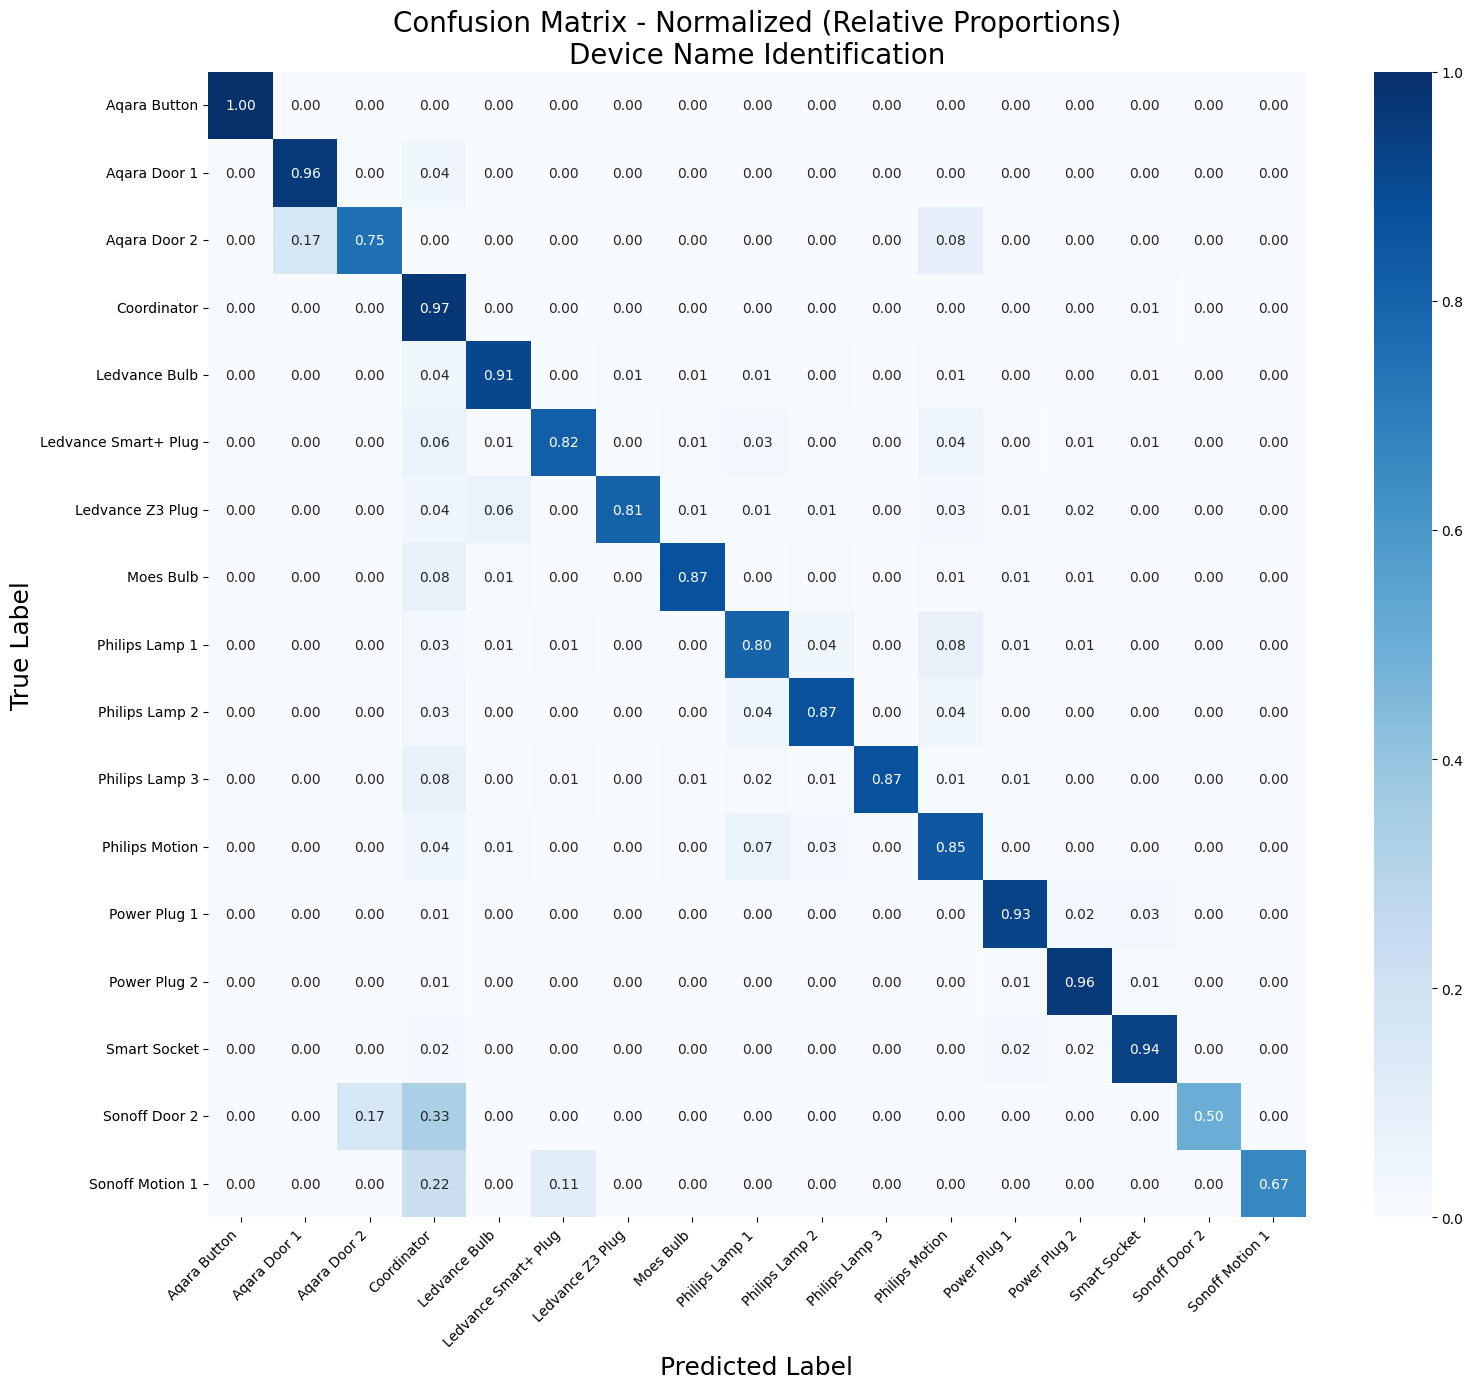


Confusion matrices saved to /mnt/user-data/outputs/
  - identification_confusion_matrix_absolute.png
  - identification_confusion_matrix_relative.png


In [4]:
# Identification with 5-Fold Cross-Validation
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=5):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Name"]

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())
print(f"\nNumber of classes: {len(categories)}")
print(f"Total samples: {len(y)}")
print()

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Train model
    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(16, 14))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Summed Over 5 Folds (Absolute Counts)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(16, 14))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Normalized (Relative Proportions)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")
print("  - identification_confusion_matrix_absolute.png")
print("  - identification_confusion_matrix_relative.png")

## Train B Test B

Category distribution:
Device Type
Socket         14573
Coordinator    11594
Bulb            4228
Motion           554
Door              45
Button            35
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.95      0.94      0.95       862
      Button       0.90      1.00      0.95         9
 Coordinator       0.98      0.97      0.97      2309
        Door       0.83      1.00      0.91         5
      Motion       0.96      0.99      0.97       117
      Socket       0.98      0.99      0.98      2904

    accuracy                           0.97      6206
   macro avg       0.93      0.98      0.96      6206
weighted avg       0.97      0.97      0.97      6206

Weighted F1-Score: 0.9745


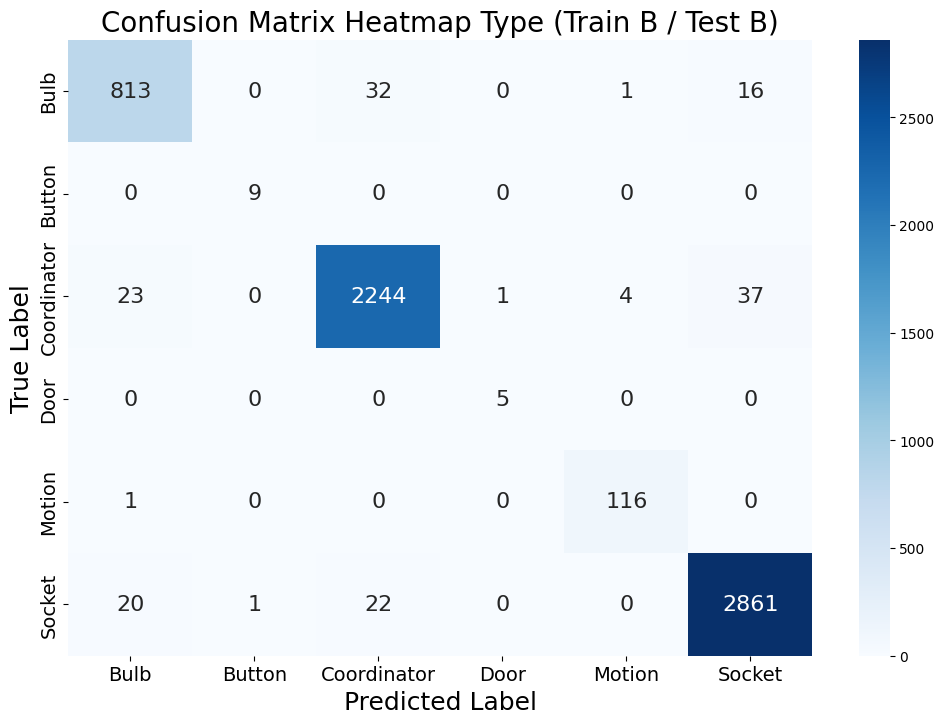

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)


X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train B / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


Category distribution:
Device Type
Socket         14573
Coordinator    11594
Bulb            4228
Motion           554
Door              45
Button            35
Name: count, dtype: int64

5-FOLD CROSS-VALIDATION RESULTS

Fold 1/5:
----------------------------------------
  Accuracy:        0.9753
  Precision (avg): 0.9201
  Recall (avg):    0.9142
  F1-Macro:        0.9170
  F1-Weighted:     0.9753

Fold 2/5:
----------------------------------------
  Accuracy:        0.9684
  Precision (avg): 0.9507
  Recall (avg):    0.9122
  F1-Macro:        0.9291
  F1-Weighted:     0.9684

Fold 3/5:
----------------------------------------
  Accuracy:        0.9733
  Precision (avg): 0.9401
  Recall (avg):    0.9429
  F1-Macro:        0.9369
  F1-Weighted:     0.9733

Fold 4/5:
----------------------------------------
  Accuracy:        0.9694
  Precision (avg): 0.9764
  Recall (avg):    0.9408
  F1-Macro:        0.9563
  F1-Weighted:     0.9694

Fold 5/5:
----------------------------------------


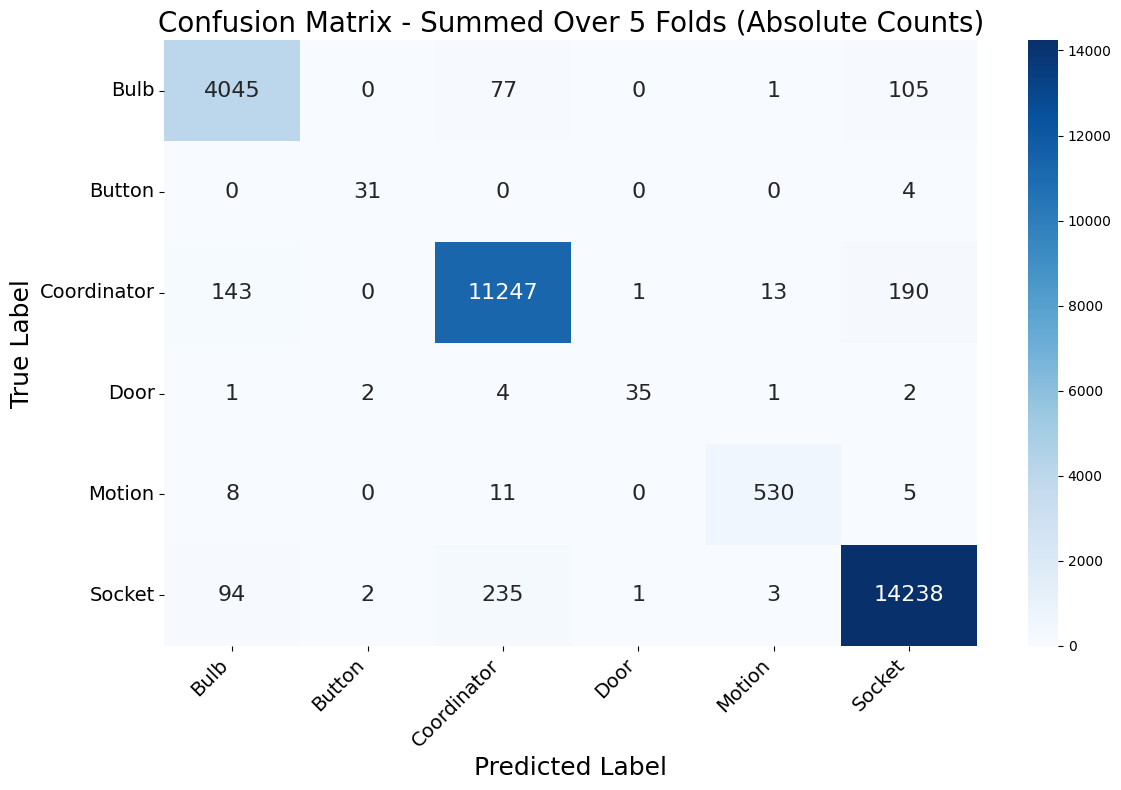

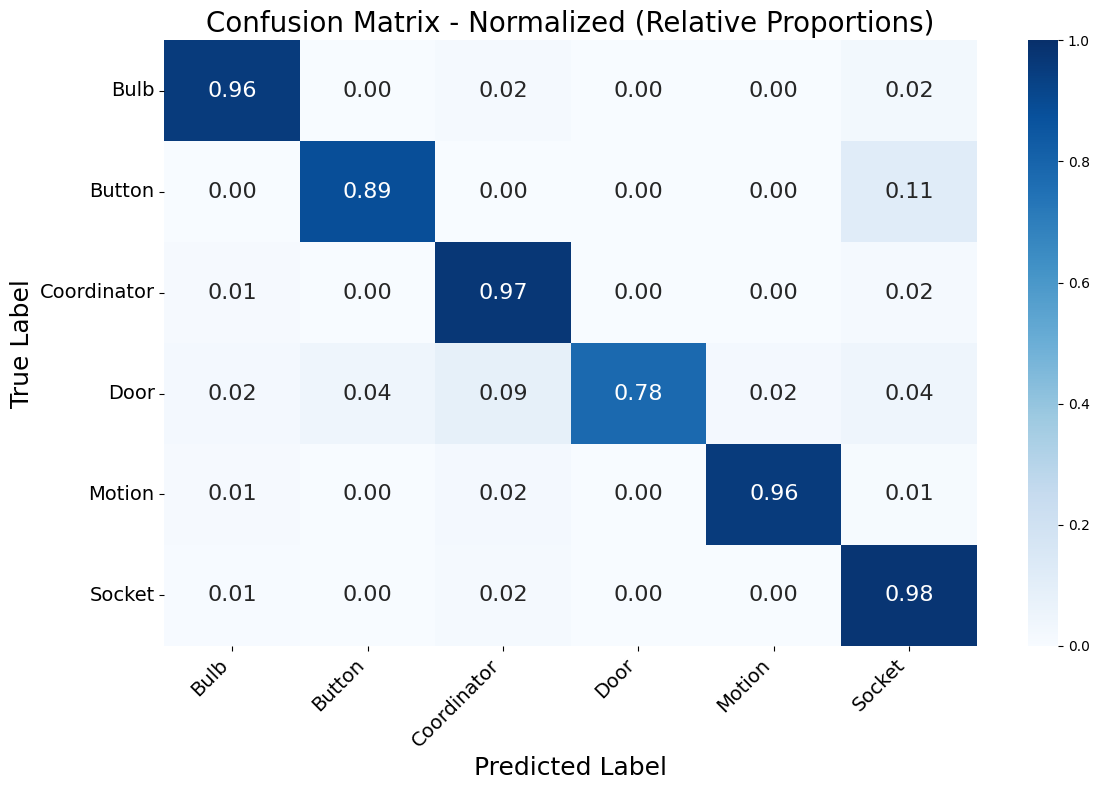


Confusion matrices saved to /mnt/user-data/outputs/


In [5]:
# Classification with 5-Fold Cross-Validation
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())
print()

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Train model
    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Summed Over 5 Folds (Absolute Counts)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(12, 8))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Normalized (Relative Proportions)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")

Category distribution:
Device Type
Socket         14573
Coordinator    11594
Bulb            4228
Motion           554
Door              45
Button            35
Name: count, dtype: int64

5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier

Fold 1/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:45:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9451
  Precision (avg): 0.8208
  Recall (avg):    0.9273
  F1-Macro:        0.8669
  F1-Weighted:     0.9456

Fold 2/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:45:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9497
  Precision (avg): 0.9225
  Recall (avg):    0.9730
  F1-Macro:        0.9458
  F1-Weighted:     0.9501

Fold 3/5:
----------------------------------------


...

  Accuracy:        0.9447
  Precision (avg): 0.8879
  Recall (avg):    0.9349
  F1-Macro:        0.9037
  F1-Weighted:     0.9455

Fold 4/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:45:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9446
  Precision (avg): 0.9028
  Recall (avg):    0.9696
  F1-Macro:        0.9326
  F1-Weighted:     0.9453

Fold 5/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [14:45:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.9483
  Precision (avg): 0.9113
  Recall (avg):    0.9574
  F1-Macro:        0.9314
  F1-Weighted:     0.9489

CROSS-VALIDATION SUMMARY (mean ± std)
Accuracy:        0.9465 ± 0.0021
Precision (avg): 0.8891 ± 0.0359
Recall (avg):    0.9524 ± 0.0183
F1-Macro:        0.9161 ± 0.0281
F1-Weighted:     0.9471 ± 0.0020

MERGED CLASSIFICATION REPORT (All Folds Combined)
              precision    recall  f1-score   support

        Bulb       0.85      0.97      0.91      4228
      Button       0.85      1.00      0.92        35
 Coordinator       0.97      0.93      0.95     11594
        Door       0.87      0.89      0.88        45
      Motion       0.79      0.97      0.87       554
      Socket       0.97      0.95      0.96     14573

    accuracy                           0.95     31029
   macro avg       0.88      0.95      0.91     31029
weighted avg       0.95      0.95      0.95     31029



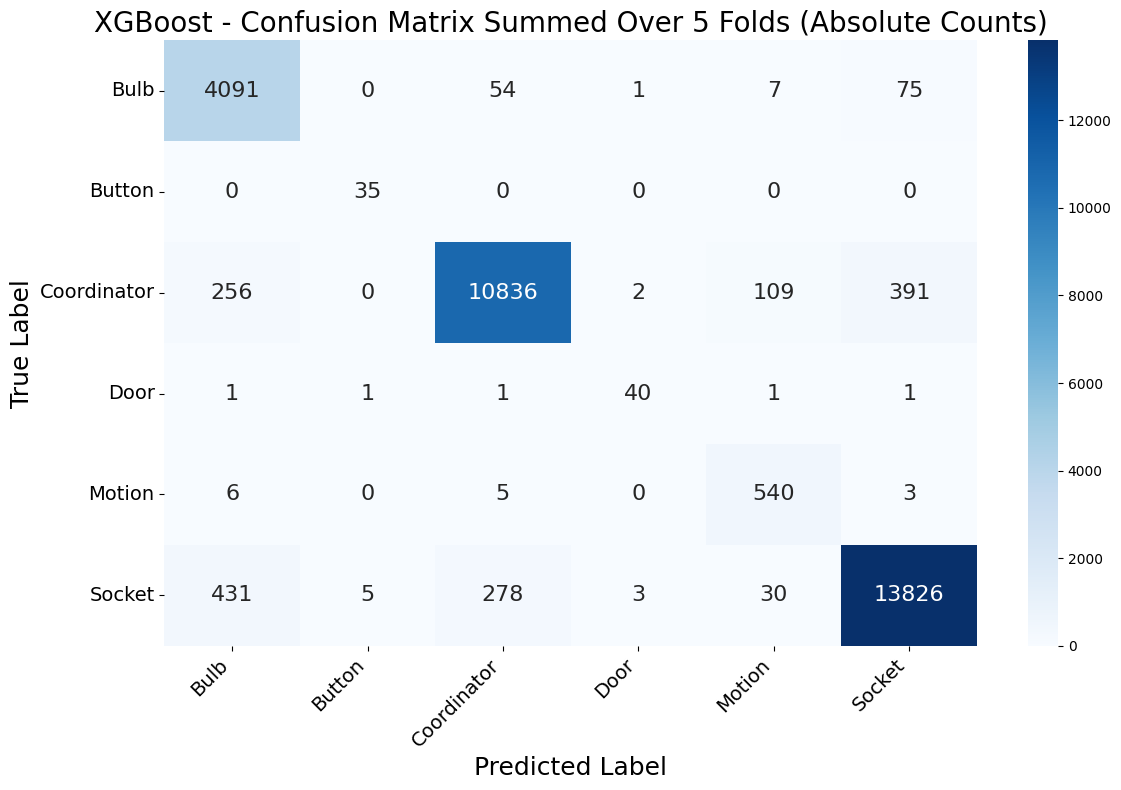

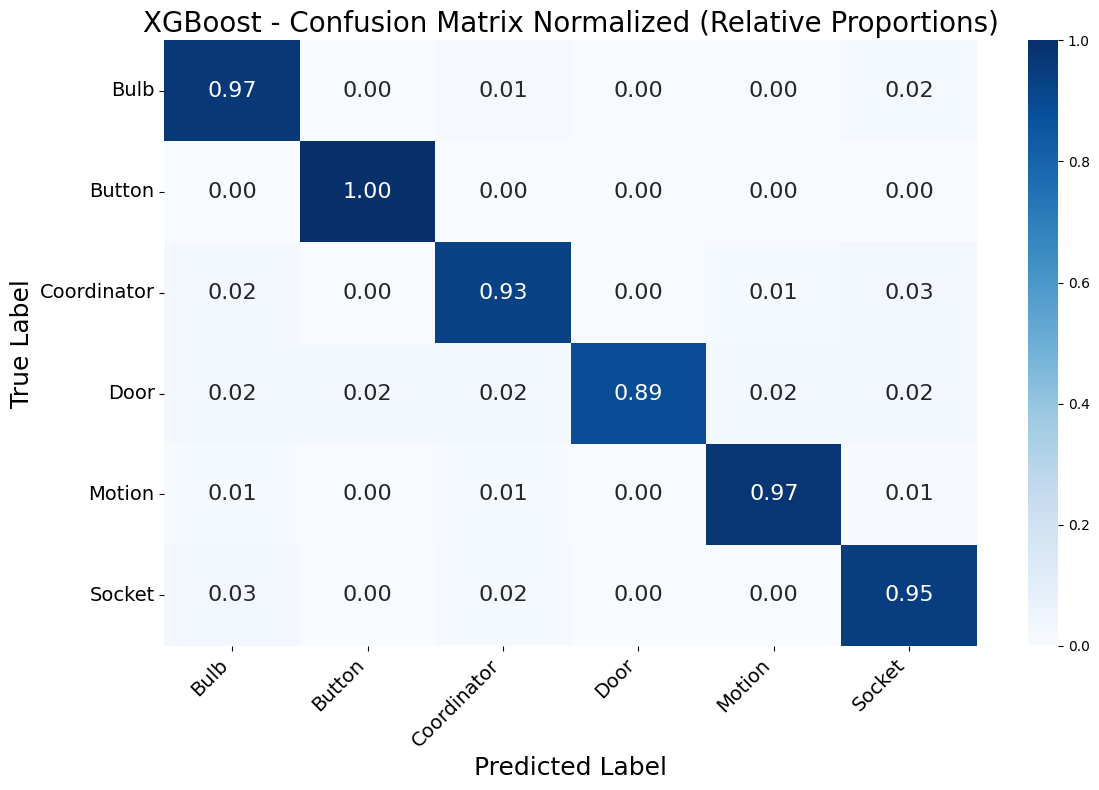


Confusion matrices saved to /mnt/user-data/outputs/


In [8]:
# Classification with 5-Fold Cross-Validation using XGBoost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Type"]

print("Category distribution:")
print(y.value_counts())
print()

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    
    # Convert class weights to sample weights for XGBoost
    sample_weights = np.array([class_weights[i] for i in y_train])
    
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    )
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predict
    y_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(12, 8))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Summed Over 5 Folds (Absolute Counts)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_xgboost_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(12, 8))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 16},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Normalized (Relative Proportions)", fontsize=20)
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/confusion_matrix_xgboost_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")

Category distribution:
4     11594
15     5506
13     4682
14     3994
5      1312
9      1184
11      942
12      511
8       405
10      385
7       321
6        70
0        35
18       33
2        29
3        10
16        6
17        5
1         5
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.90      1.00      0.95         9
        Aqara Door 1       1.00      1.00      1.00         1
        Aqara Door 2       1.00      1.00      1.00         2
        Aqara Motion       1.00      1.00      1.00         1
         Coordinator       0.97      0.97      0.97      2309
       Ledvance Bulb       0.94      0.88      0.91       284
Ledvance Smart+ Plug       0.91      0.91      0.91        11
    Ledvance Z3 Plug       0.85      0.66      0.75        62
           Moes Bulb       0.98      0.91      0.94        92
      Philips Lamp 1       0.89      0.93      0.91       232
      Philips Lamp 2       0.90      0.8

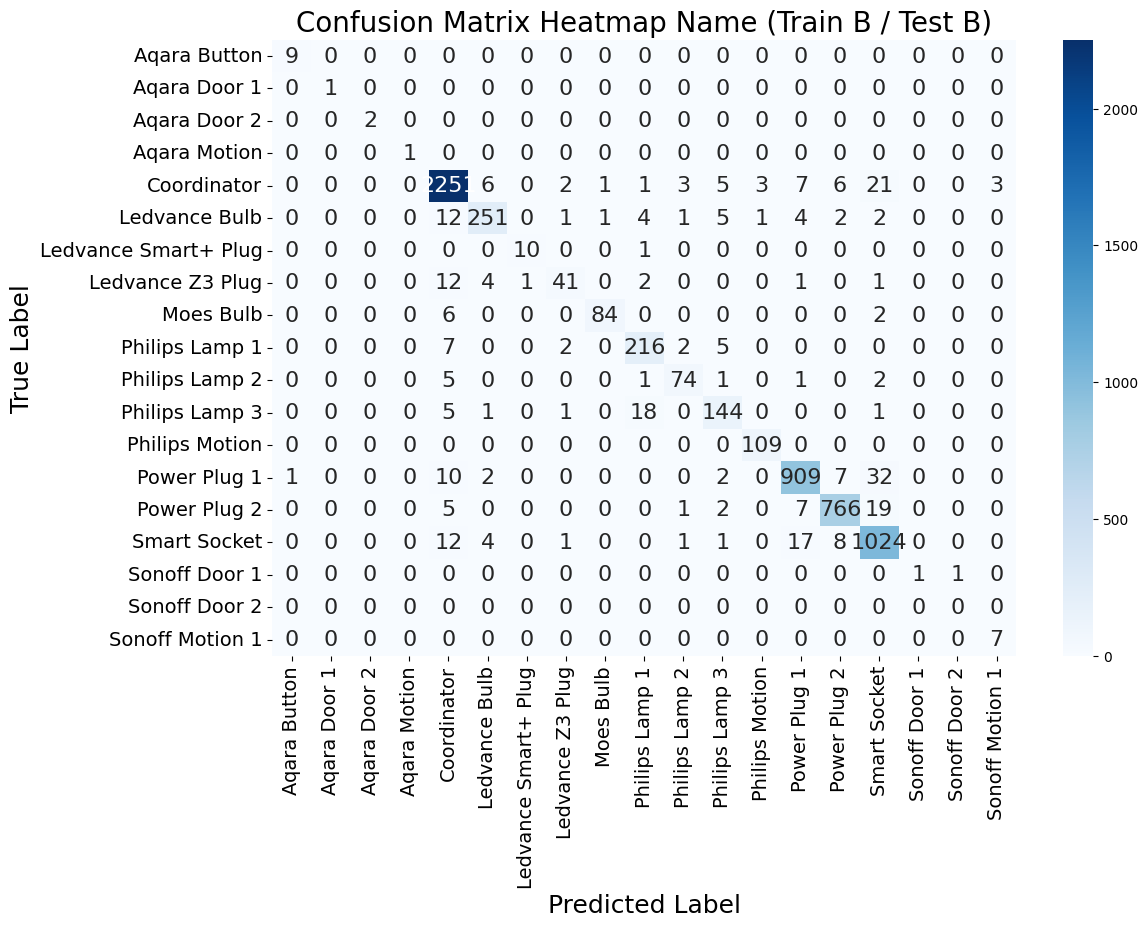

In [11]:
# Identification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=5):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train B / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
3     11594
10     8676
11     5506
8      2511
4      1312
9       511
7       405
6       321
5        70
0        35
1        34
13       33
12       11
2        10
Name: count, dtype: int64

Number of classes: 14
Total samples: 31029

5-FOLD CROSS-VALIDATION RESULTS

Fold 1/5:
----------------------------------------
  Accuracy:        0.9578
  Precision (avg): 0.9230
  Recall (avg):    0.9323
  F1-Macro:        0.9249
  F1-Weighted:     0.9577

Fold 2/5:
----------------------------------------
  Accuracy:        0.9568
  Precision (avg): 0.9242
  Recall (avg):    0.9204
  F1-Macro:        0.9178
  F1-Weighted:     0.9567

Fold 3/5:
----------------------------------------
  Accuracy:        0.9602
  Precision (avg): 0.9278
  Recall (avg):    0.8713
  F1-Macro:        0.8886
  F1-Weighted:     0.9601

Fold 4/5:
----------------------------------------
  Accuracy:        0.9549
  Precision (avg): 0.9443
  Recall (avg):    0.8800
  F1-Macro:        0.9042
  F1

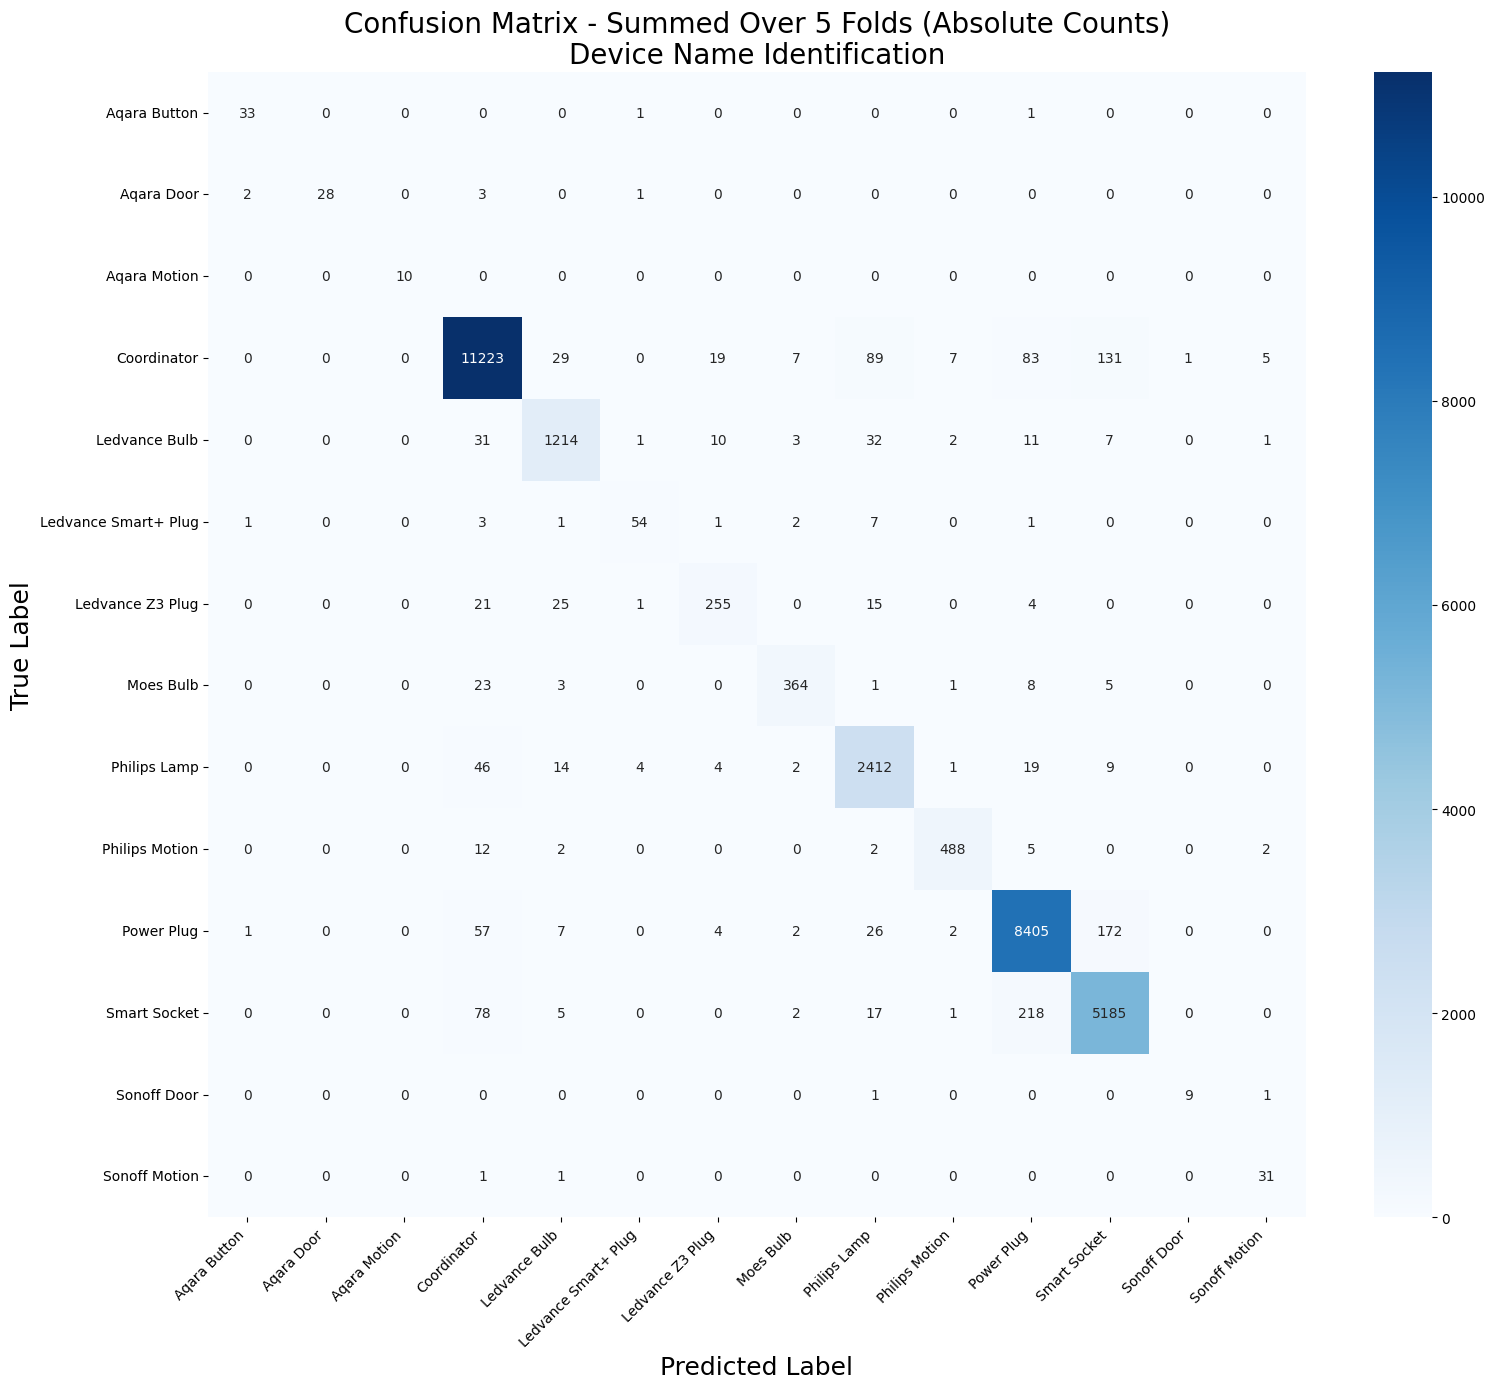

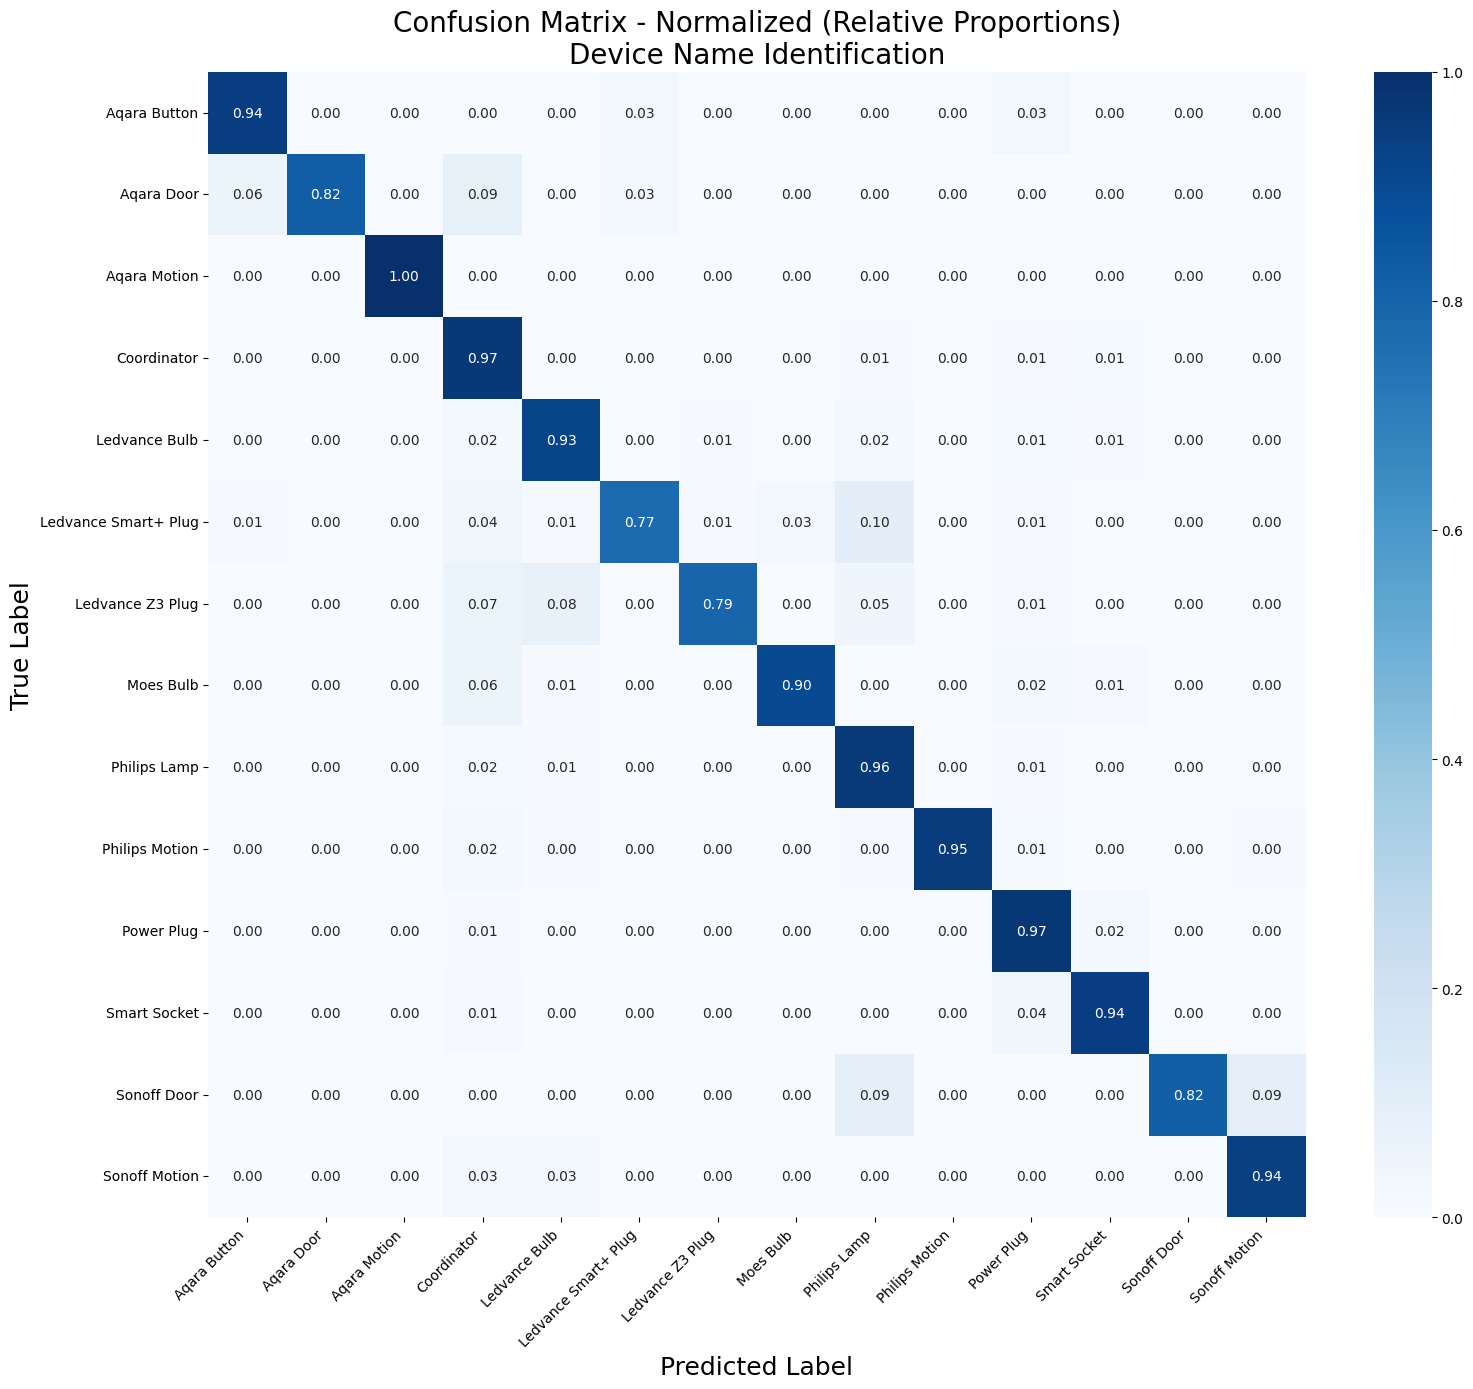


Confusion matrices saved to /mnt/user-data/outputs/
  - identification_confusion_matrix_absolute.png
  - identification_confusion_matrix_relative.png


In [6]:
# Identification with 5-Fold Cross-Validation
import pandas as pd
import re
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, col_name = "Device Name",  min_samples=5):
    class_counts = data[col_name].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data[col_name].isin(classes_to_keep)].copy()
    return filtered_data

def generalize_device_name(name):
    """Remove trailing numbers and spaces from device name"""
    # Remove trailing digits and spaces (e.g., "Device 1" -> "Device", "Camera2" -> "Camera")
    generalized = re.sub(r'\s*\d+\s*$', '', str(name)).strip()
    return generalized

data["Device Name General"] = data["Device Name"].apply(generalize_device_name)

data = filter_small_classes(data, col_name="Device Name General", min_samples=10)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name","Device Name General"])



y = data["Device Name General"]

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())
print(f"\nNumber of classes: {len(categories)}")
print(f"Total samples: {len(y)}")
print()

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    
    # Train model
    rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
    rf_model.fit(X_train, y_train)
    
    # Predict
    y_pred = rf_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(16, 14))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Summed Over 5 Folds (Absolute Counts)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(16, 14))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix - Normalized (Relative Proportions)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")
print("  - identification_confusion_matrix_absolute.png")
print("  - identification_confusion_matrix_relative.png")

Category distribution:
4     11594
15     5506
13     4682
14     3994
5      1312
9      1184
11      942
12      511
8       405
10      385
7       321
6        70
0        35
18       33
2        29
3        10
16        6
17        5
1         5
Name: count, dtype: int64

Number of classes: 19
Total samples: 31029

5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier

Fold 1/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:45:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.8447
  Precision (avg): 0.7586
  Recall (avg):    0.8077
  F1-Macro:        0.7737
  F1-Weighted:     0.8470

Fold 2/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:45:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.8447
  Precision (avg): 0.7443
  Recall (avg):    0.8888
  F1-Macro:        0.7960
  F1-Weighted:     0.8473

Fold 3/5:
----------------------------------------


...

  Accuracy:        0.8340
  Precision (avg): 0.8134
  Recall (avg):    0.9005
  F1-Macro:        0.8447
  F1-Weighted:     0.8370

Fold 4/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:46:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.8450
  Precision (avg): 0.8318
  Recall (avg):    0.9209
  F1-Macro:        0.8707
  F1-Weighted:     0.8473

Fold 5/5:
----------------------------------------


/home/antonio/.conda/envs/ziot/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:46:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy:        0.8434
  Precision (avg): 0.7641
  Recall (avg):    0.8504
  F1-Macro:        0.8002
  F1-Weighted:     0.8455

CROSS-VALIDATION SUMMARY (mean ± std)
Accuracy:        0.8423 ± 0.0042
Precision (avg): 0.7825 ± 0.0339
Recall (avg):    0.8737 ± 0.0402
F1-Macro:        0.8171 ± 0.0353
F1-Weighted:     0.8448 ± 0.0040

MERGED CLASSIFICATION REPORT (All Folds Combined)
                      precision    recall  f1-score   support

        Aqara Button       0.85      1.00      0.92        35
        Aqara Door 1       0.83      1.00      0.91         5
        Aqara Door 2       0.86      0.83      0.84        29
        Aqara Motion       1.00      1.00      1.00        10
         Coordinator       0.99      0.90      0.94     11594
       Ledvance Bulb       0.86      0.91      0.88      1312
Ledvance Smart+ Plug       0.62      0.83      0.71        70
    Ledvance Z3 Plug       0.71      0.83      0.77       321
           Moes Bulb       0.75      0.95      0.84     

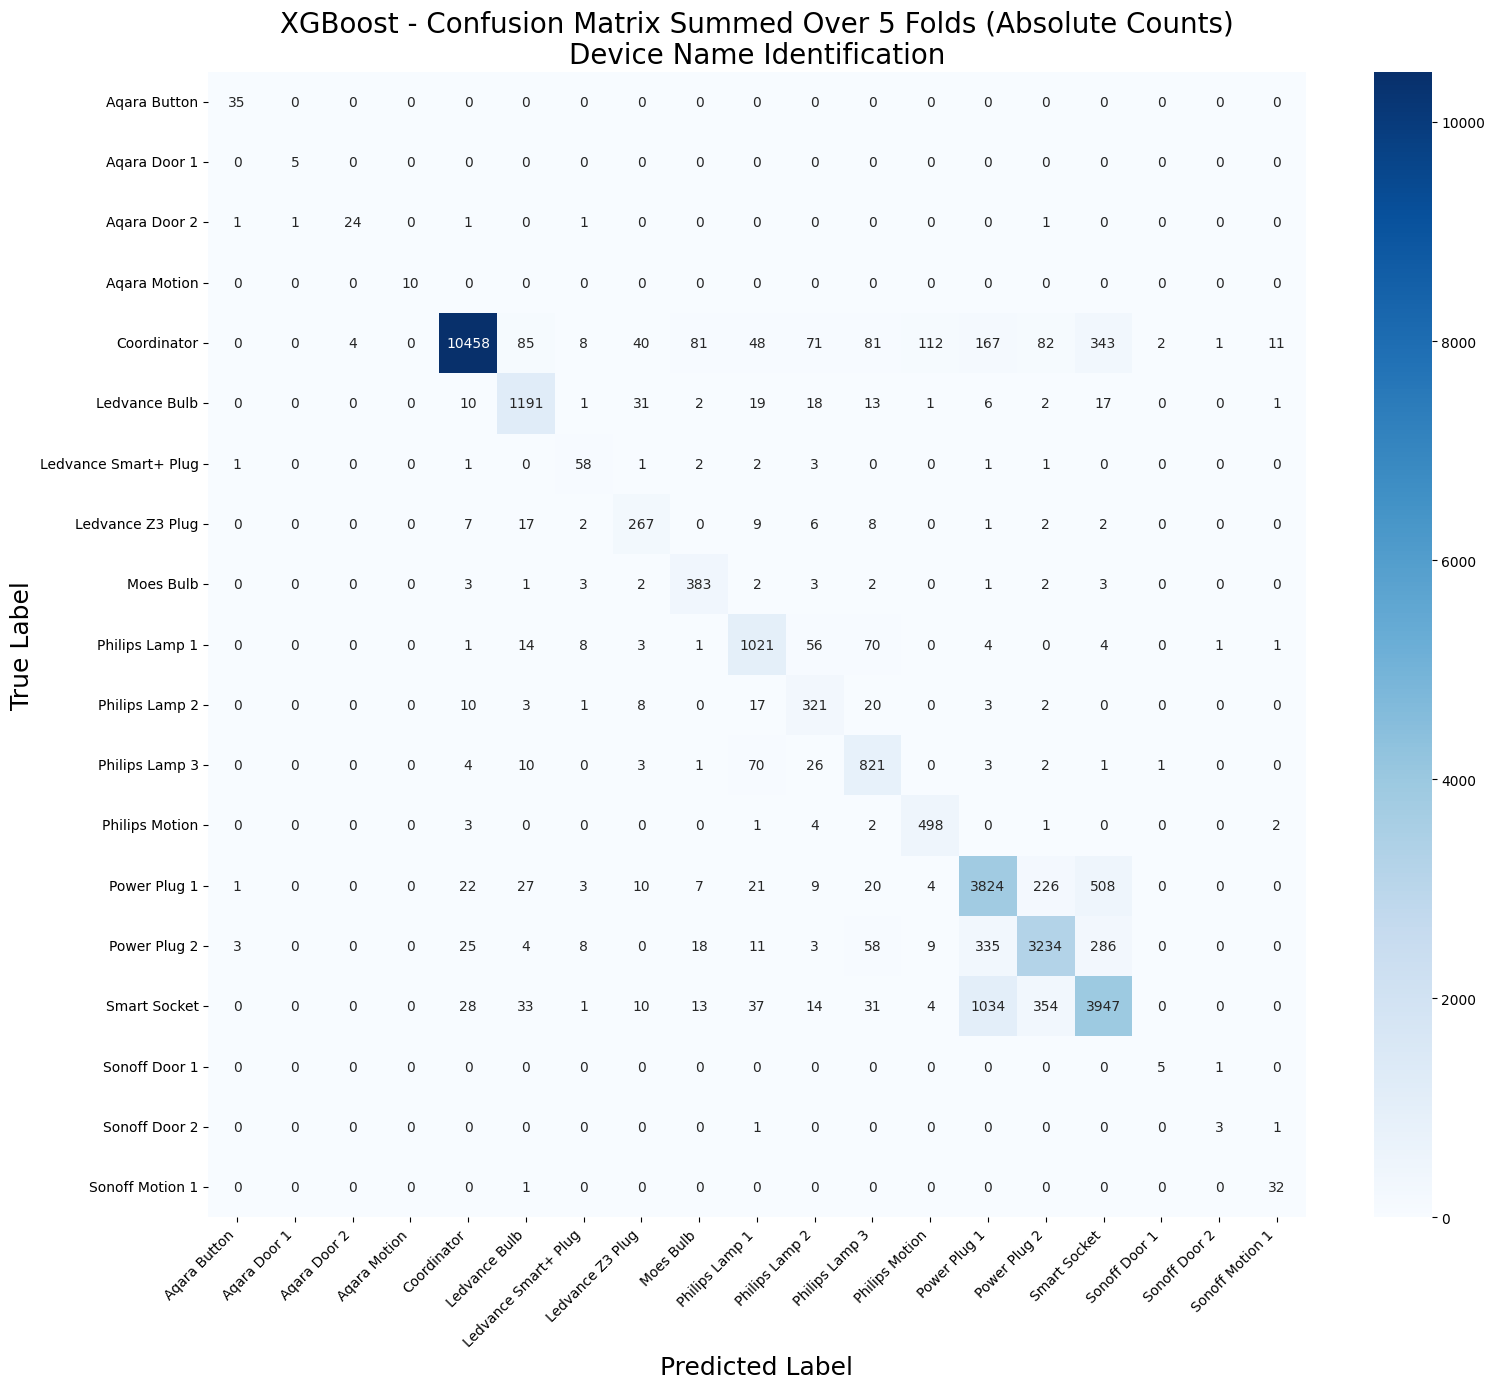

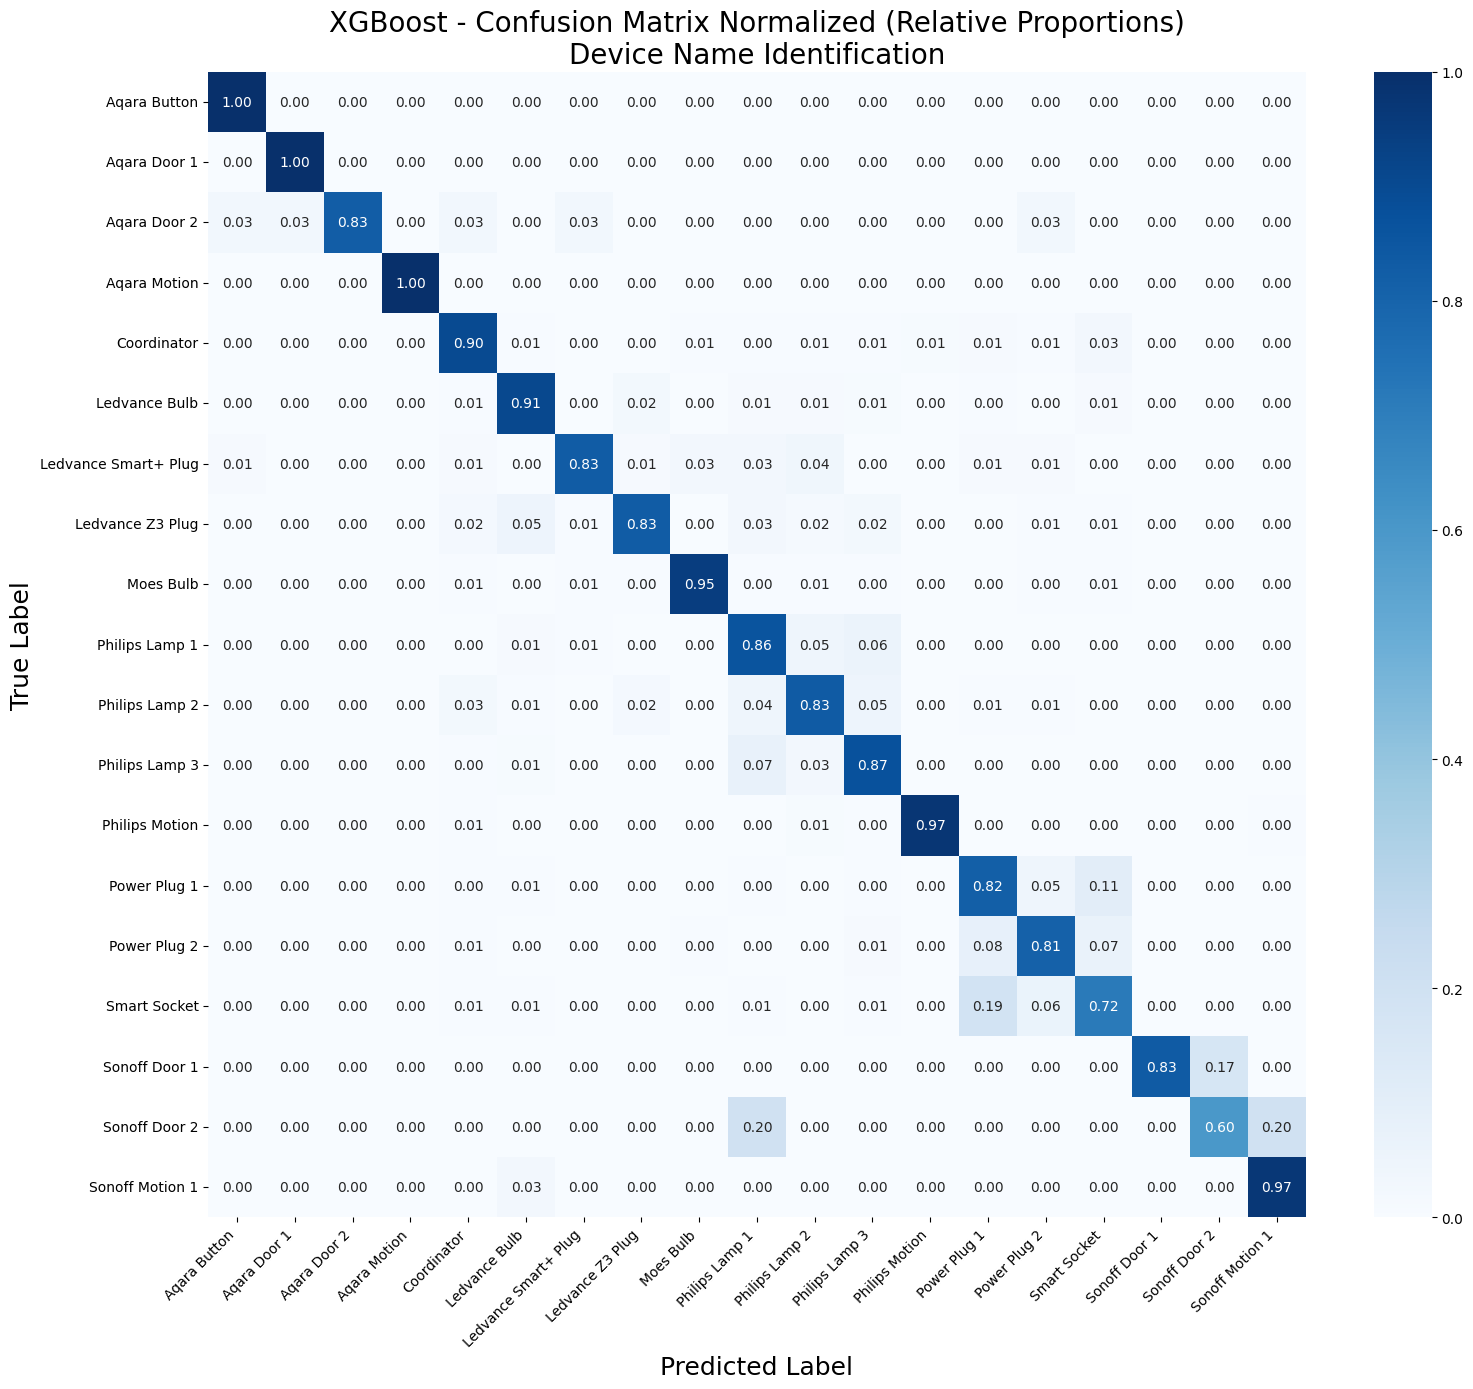


Confusion matrices saved to /mnt/user-data/outputs/
  - identification_xgboost_confusion_matrix_absolute.png
  - identification_xgboost_confusion_matrix_relative.png


In [15]:
# Identification with 5-Fold Cross-Validation using XGBoost
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# Load data
file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
data = pd.read_csv(file_path)

def filter_small_classes(data, min_samples=2):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

data = filter_small_classes(data)

# Prepare features and target
X = data.drop(columns=["Device Name", "Device Type", "File Name"])
y = data["Device Name"]

# Convert to category codes
y = y.astype('category')
categories = y.cat.categories
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())
print(f"\nNumber of classes: {len(categories)}")
print(f"Total samples: {len(y)}")
print()

# Initialize 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
f1_macro_scores = []
f1_weighted_scores = []
precision_scores = []
recall_scores = []

# Storage for confusion matrices
all_confusion_matrices = []

# Storage for all predictions and true labels
all_y_test = []
all_y_pred = []

print("=" * 80)
print("5-FOLD CROSS-VALIDATION RESULTS - XGBoost Classifier")
print("=" * 80)

# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}/5:")
    print("-" * 40)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Compute class weights
    class_weights = compute_class_weight(
        class_weight="balanced", 
        classes=np.unique(y_train), 
        y=y_train
    )
    
    # Convert class weights to sample weights for XGBoost
    sample_weights = np.array([class_weights[i] for i in y_train])
    
    # Train XGBoost model
    xgb_model = XGBClassifier(
        random_state=42,
        eval_metric='mlogloss',  # For multi-class classification
        use_label_encoder=False,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    )
    xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
    
    # Predict
    y_pred = xgb_model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    
    # Get classification report for precision and recall
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']
    
    # Store metrics
    accuracy_scores.append(accuracy)
    f1_macro_scores.append(f1_macro)
    f1_weighted_scores.append(f1_weighted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    # Store confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=range(len(categories)))
    all_confusion_matrices.append(cm)
    
    # Store predictions and true labels
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Print fold results
    print(f"  Accuracy:        {accuracy:.4f}")
    print(f"  Precision (avg): {precision:.4f}")
    print(f"  Recall (avg):    {recall:.4f}")
    print(f"  F1-Macro:        {f1_macro:.4f}")
    print(f"  F1-Weighted:     {f1_weighted:.4f}")

# Calculate mean and standard deviation
print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY (mean ± std)")
print("=" * 80)
print(f"Accuracy:        {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision (avg): {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall (avg):    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1-Macro:        {np.mean(f1_macro_scores):.4f} ± {np.std(f1_macro_scores):.4f}")
print(f"F1-Weighted:     {np.mean(f1_weighted_scores):.4f} ± {np.std(f1_weighted_scores):.4f}")
print("=" * 80)

# Generate merged classification report from all folds
print("\n" + "=" * 80)
print("MERGED CLASSIFICATION REPORT (All Folds Combined)")
print("=" * 80)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

merged_report = classification_report(
    all_y_test, 
    all_y_pred, 
    target_names=categories, 
    labels=range(len(categories)),
    zero_division=0
)
print(merged_report)
print("=" * 80)

# Sum all confusion matrices
summed_cm = np.sum(all_confusion_matrices, axis=0)

# Create relative (normalized) confusion matrix
relative_cm = summed_cm.astype('float') / summed_cm.sum(axis=1)[:, np.newaxis]

# Plot 1: Summed confusion matrix (absolute counts)
plt.figure(figsize=(16, 14))
sns.heatmap(
    summed_cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10}
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Summed Over 5 Folds (Absolute Counts)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_xgboost_confusion_matrix_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Relative confusion matrix (normalized by row)
plt.figure(figsize=(16, 14))
sns.heatmap(
    relative_cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=categories, 
    yticklabels=categories, 
    annot_kws={"size": 10},
    vmin=0,
    vmax=1
)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("XGBoost - Confusion Matrix Normalized (Relative Proportions)\nDevice Name Identification", fontsize=20)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/identification_xgboost_confusion_matrix_relative.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nConfusion matrices saved to /mnt/user-data/outputs/")
print("  - identification_xgboost_confusion_matrix_absolute.png")
print("  - identification_xgboost_confusion_matrix_relative.png")

## Train A Test B

Category distribution:
2    8650
5    8300
0    3839
4     206
3      69
1      17
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.65      0.82      0.73      4228
      Button       0.71      0.63      0.67        35
 Coordinator       0.88      0.93      0.90     11594
        Door       0.57      0.64      0.60        45
      Motion       0.87      0.57      0.69       554
      Socket       0.93      0.83      0.88     14573

    accuracy                           0.86     31029
   macro avg       0.77      0.74      0.75     31029
weighted avg       0.87      0.86      0.86     31029

Weighed F1-Score: 0.8632


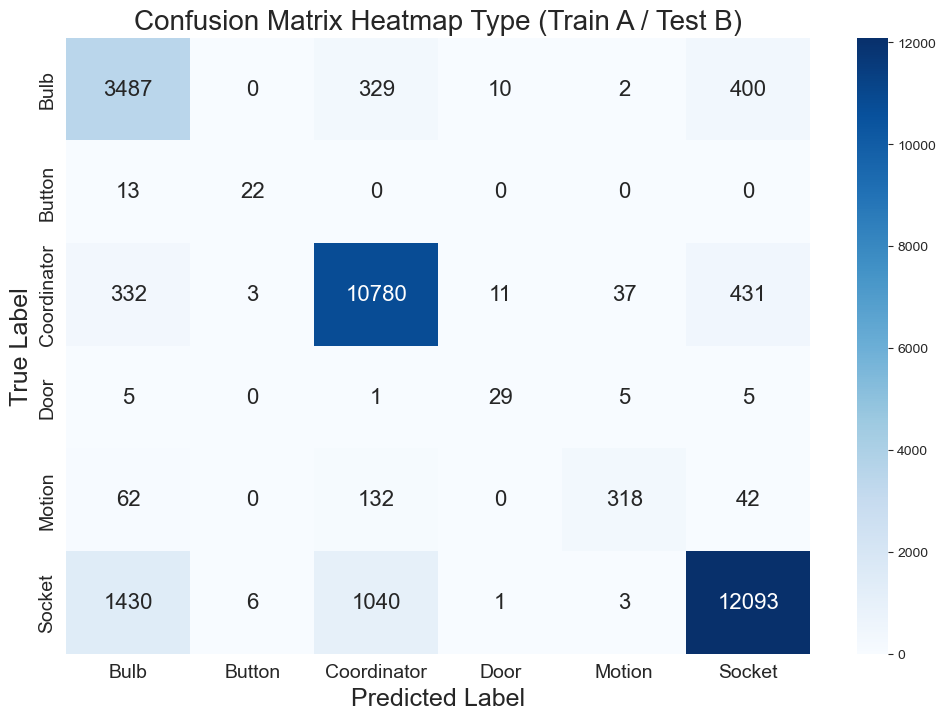

In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data[feature_columns]
y_test = test_data["Device Type"]

y_test = test_data["Device Type"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighed F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
2     8650
13    2949
12    2606
11    2385
3     1165
10     742
6      726
7      669
8      537
5      221
9      194
4      139
1       50
0       17
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.70      0.60      0.65        35
        Aqara Door 1       0.00      0.00      0.00         0
         Coordinator       0.85      0.93      0.89     11594
       Ledvance Bulb       0.63      0.67      0.65      1312
Ledvance Smart+ Plug       0.30      0.19      0.23        70
    Ledvance Z3 Plug       0.05      0.04      0.05       321
           Moes Bulb       0.25      0.55      0.34       405
      Philips Lamp 1       0.37      0.23      0.29      1184
      Philips Lamp 2       0.06      0.14      0.08       385
      Philips Lamp 3       0.00      0.00      0.00       942
      Philips Motion       0.01      0.01      0.01       511
        Power Plug 1       0.44      0.33      0.38 

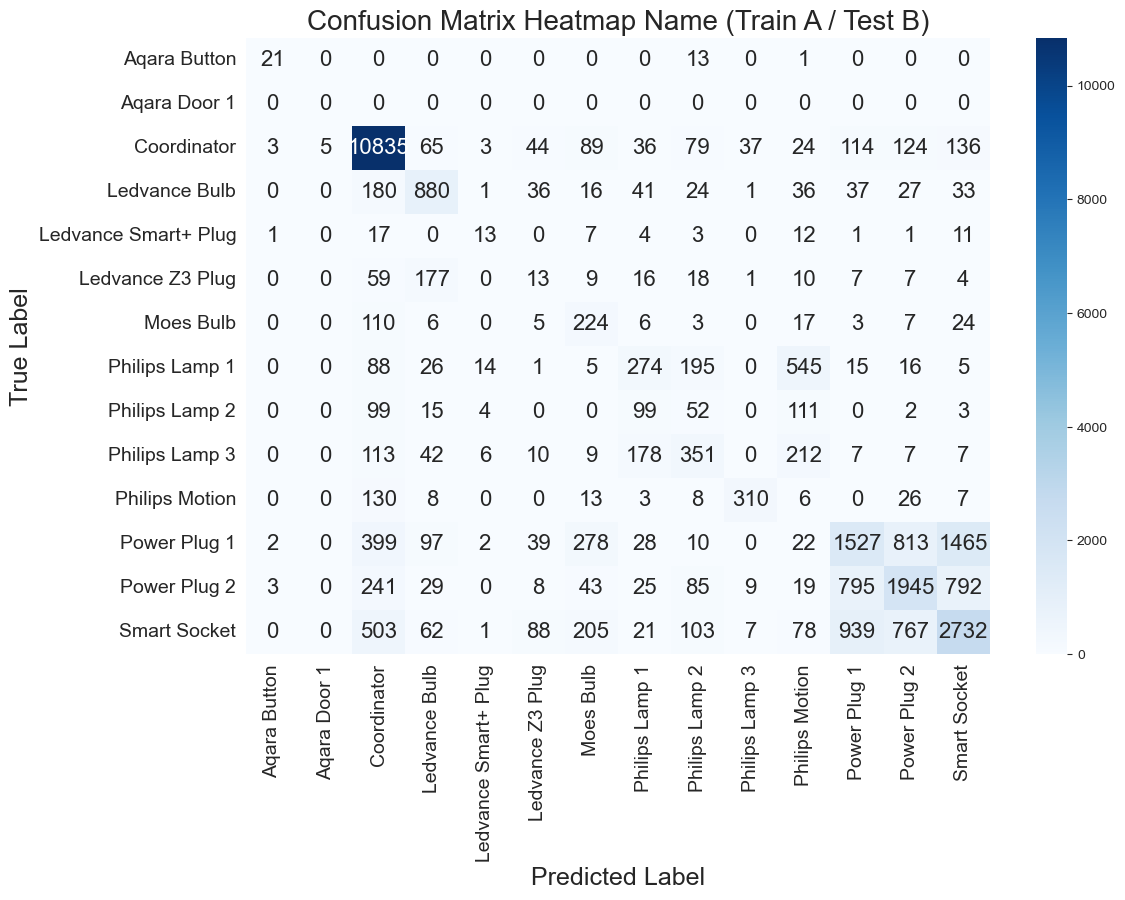

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)
train_data = filter_small_classes(train_data)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)
test_data = filter_small_classes(test_data)

X_test = test_data[feature_columns]
y_test = test_data["Device Name"]

y_test = test_data["Device Name"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train A / Test B)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

## Train B Test A

Category distribution:
5    14573
2    11594
0     4228
4      554
3       45
1       35
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.83      0.72      0.77      3839
      Button       0.55      0.35      0.43        17
 Coordinator       0.88      0.82      0.85      8650
        Door       0.89      0.46      0.61        69
      Motion       0.63      0.50      0.56       206
      Socket       0.80      0.91      0.85      8300

    accuracy                           0.83     21081
   macro avg       0.76      0.63      0.68     21081
weighted avg       0.84      0.83      0.83     21081

Weighed F1-Score: 0.8317


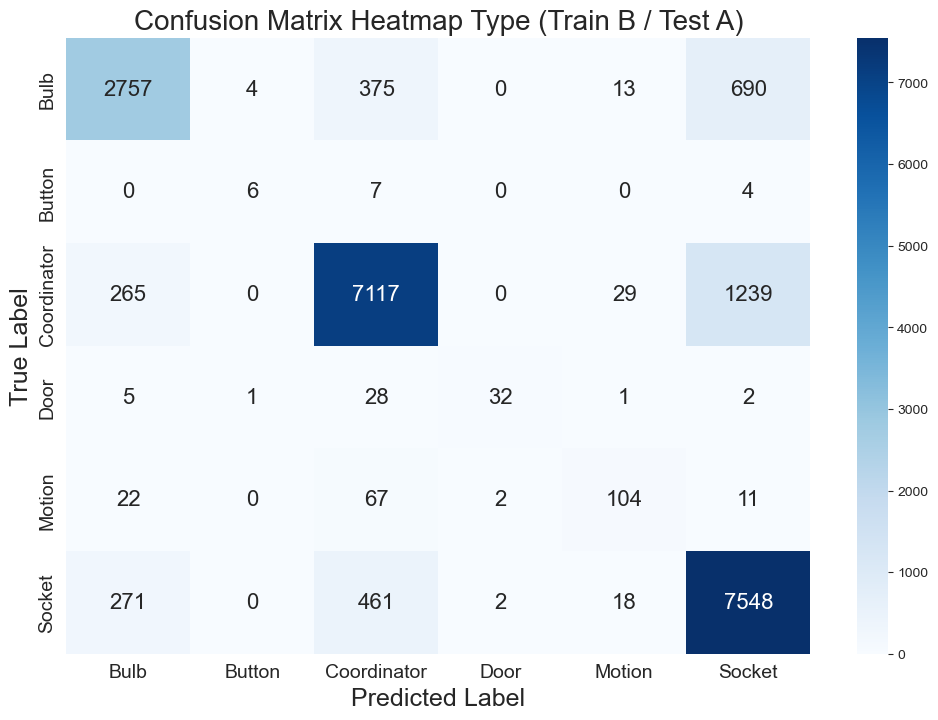

In [18]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

# 加载测试数据
test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data[feature_columns]
y_test = test_data["Device Type"]

y_test = test_data["Device Type"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighed F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Type (Train B / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Category distribution:
2     11594
13     5506
11     4682
12     3994
3      1312
7      1184
9       942
10      511
6       405
8       385
5       321
4        70
0        35
14       33
1        29
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.60      0.35      0.44        17
         Coordinator       0.87      0.84      0.85      8650
       Ledvance Bulb       0.69      0.67      0.68      1165
Ledvance Smart+ Plug       0.24      0.06      0.10       139
    Ledvance Z3 Plug       0.15      0.07      0.09       221
           Moes Bulb       0.69      0.19      0.29       726
      Philips Lamp 1       0.30      0.47      0.36       669
      Philips Lamp 2       0.19      0.09      0.12       537
      Philips Lamp 3       0.00      0.01      0.00       194
      Philips Motion       0.01      0.00      0.00       742
        Power Plug 1       0.35      0.37      0.36      2385
        Power Plug 2      

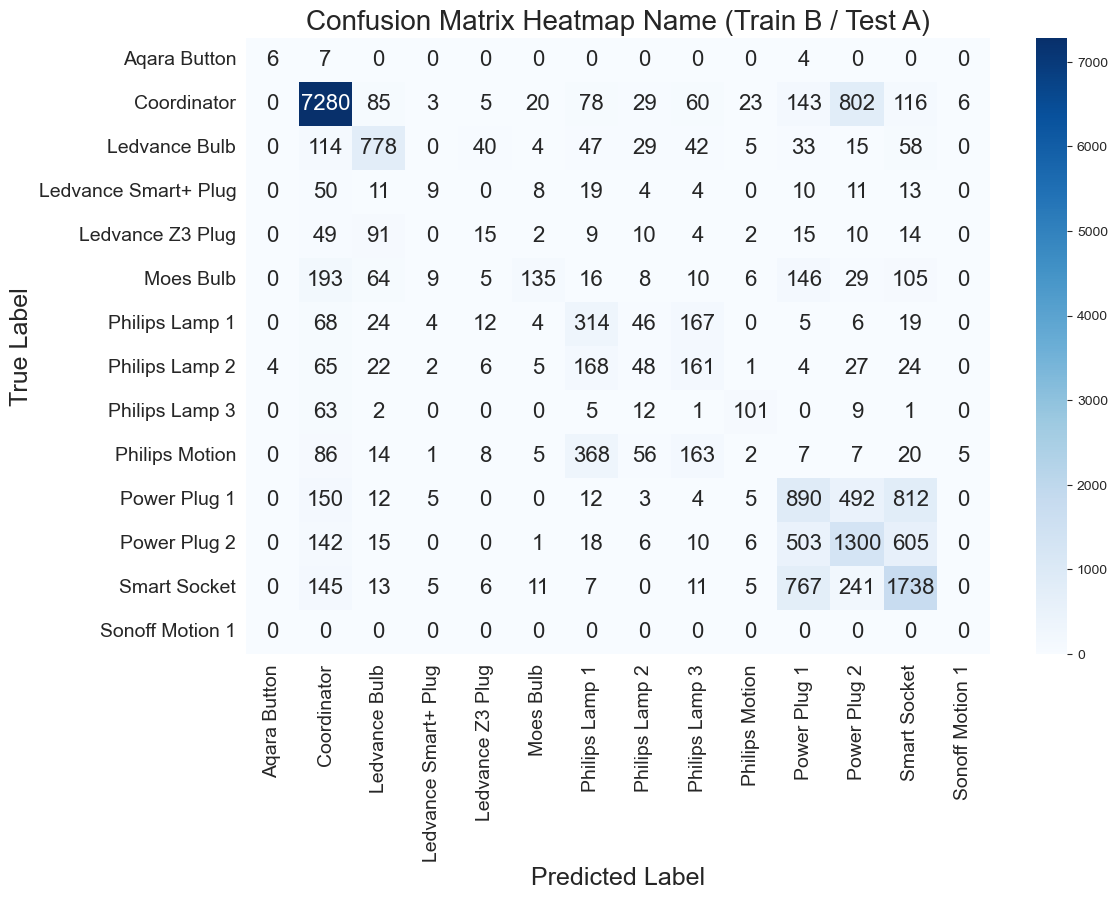

In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

def filter_small_classes(data, min_samples=15):
    class_counts = data["Device Name"].value_counts()
    classes_to_keep = class_counts[class_counts >= min_samples].index.tolist()
    filtered_data = data[data["Device Name"].isin(classes_to_keep)].copy()
    return filtered_data

train_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_B_fix_duration_5s.csv"
train_data = pd.read_csv(train_file_path)
train_data = filter_small_classes(train_data)

X_train = train_data.drop(columns=["Device Name", "Device Type", "File Name"])
feature_columns = X_train.columns.tolist()
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "6-Merged_Data/6-Merged_sequence_data_fix_durations/Topology_A_fix_duration_5s.csv"
test_data = pd.read_csv(test_file_path)
test_data = filter_small_classes(test_data)

X_test = test_data[feature_columns]
y_test = test_data["Device Name"]

y_test = test_data["Device Name"].astype(pd.api.types.CategoricalDtype(categories=categories))
y_test = y_test.cat.codes

valid_indices = y_test.isin(pd.Series(y_train).unique())
y_test_filtered = y_test[valid_indices]
X_test_filtered = X_test.loc[valid_indices]

unique_classes = pd.Series(y_train).unique()
class_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=y_train)
class_weight_dict = {i: weight for i, weight in zip(unique_classes, class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test_filtered)

actual_categories = sorted(set(y_test_filtered) | set(y_pred))
target_names = [categories[i] for i in actual_categories if i < len(categories)]

cm = confusion_matrix(y_test_filtered, y_pred, labels=actual_categories)

report = classification_report(y_test_filtered, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test_filtered, y_pred, average="weighted")
print(f"Weighted F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 16})
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.title("Confusion Matrix Heatmap Name (Train B / Test A)", fontsize=20)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()